#### 4.1

In [5]:
x = [1, 2, 3 ,10]
y = [10, 20, 30, 40]
z1 = zip(x, y) #zip
z2 = [c1 + c2 for c1, c2 in zip(x,y)] #one liner zip
print(list(z1))
print(list(z2))

def plus(a, b): #Definition of the function
    plus = a + b
    return plus
addition = map(plus, x, y) #Map, function, one variable, second variable
print(list(addition))

[(1, 10), (2, 20), (3, 30), (10, 40)]
[11, 22, 33, 50]
[11, 22, 33, 50]


#### 4.3

In [62]:
import numpy as np


input_rps = input("What do you want to play? R for Rock, S for Scissors, P for paper:")
print(input_rps) #Making sure the input is correct
    
possibilities = np.array(['R', 'P', 'S']) #Definitions for indexes of random numbers
#0 is Rock, 1 is Paper, 2 is Scissors
computer_p = np.random.randint(0, len(possibilities))
if input_rps=="R":
    if computer_p==0: #Rock-Rock
        print("It's a draw, try again")
    elif computer_p==2: #Rock-Scissors
        print("Good job, here is your prize: You can go home")
    else: #Rock-Paper
        print("Lol you lost")
elif input_rps=="P":
    if computer_p==1: #Paper-Paper
        print("It's a draw, try again")
    elif computer_p==0: #Paper-Rock
        print("Good job, here is your prize: You can go home")
    else: #Paper-Scissors
        print("Lol you lost")
elif input_rps=="S":
    if computer_p==2: #Scissors-Scissors
        print("It's a draw, try again")
    elif computer_p==1: #Scissors-Paper
        print("Good job, here is your prize: You can go home")
    else: #Scissors-Rock
        print("Lol you lost")
else: #Wrong Input
    print("Sideye")

What do you want to play? R for Rock, S for Scissors, P for paper:P
P
It's a draw, try again


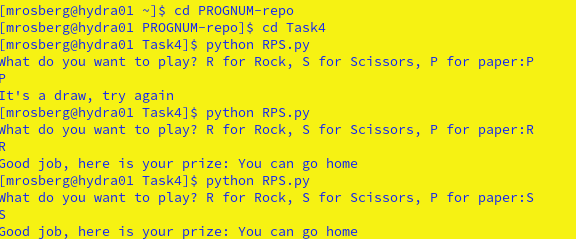

#### 4.4

Mean: 184.9509597639954
STD: 7.995362669898979


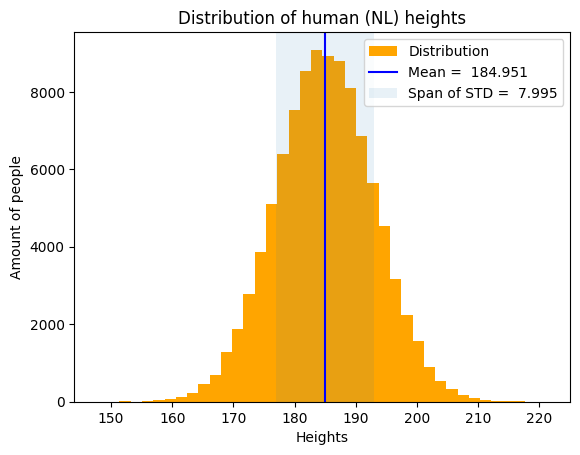

Desired height:186
Probability of a smaller height than 186.0:  54.974 %
Probability of a height between 178.0 and 194.0:  67.892 %


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sct

N_mean = 185
std = 8

STD_1 = N_mean - std
STD_2 = N_mean + std

Distribution = np.random.normal(N_mean, std, 100000)

Distribution_mean = np.mean(Distribution)
Distribution_std = np.std(Distribution)

print("Mean:", Distribution_mean)
print("STD:", Distribution_std)
plt.title("Distribution of human (NL) heights")
plt.hist(Distribution, bins=40, color='orange', label="Distribution")
plt.xlabel("Heights")
plt.ylabel("Amount of people")
plt.axvline(Distribution_mean, color='blue', label=f'Mean = {Distribution_mean: .3f}')
plt.axvspan(STD_1, STD_2, label=f'Span of STD = {Distribution_std: .3f}', alpha=0.1)
plt.legend()
plt.show()

height = float(input("Desired height:"))
probability_1a = sct.norm.cdf(height, loc=N_mean, scale=std)
probability_1 = probability_1a*100
print(f'Probability of a smaller height than {height}: {probability_1: .3f} %')

lower_limit = height - std
upper_limit = height + std

probability_2a = sct.norm.cdf(upper_limit, loc=N_mean, scale=std) - sct.norm.cdf(lower_limit, loc=N_mean, scale=std)
probability_2 = probability_2a * 100
print(f'Probability of a height between {lower_limit} and {upper_limit}: {probability_2: .3f} %')

#### 4.6

In [20]:
import numpy as np

input_func = input("Desired function letter:")
a = float(input("Lower boundary:"))
b = float(input("Higher boundary:"))

def integral(input_func, x, y):
    x = np.random.uniform(a, b, 100000)
    y = eval(input_func)
    
    intg = (b - a) * np.mean(y)
    
    return intg
print(f'{integral(input_func, a, b): .3f}')

Desired function letter:x**3
Lower boundary:0
Higher boundary:1
 0.251


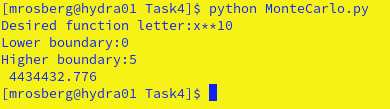

#### 4.12

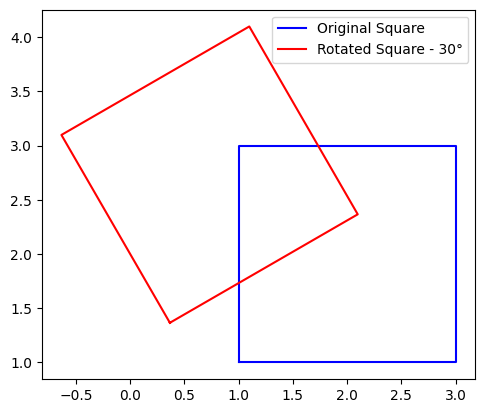

In [42]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

angle = 30

z = x + y*1j #Conversion to Complex numbers

theta = np.deg2rad(angle) #Converting deg to rad

rotation = np.exp(1j * theta) #Rotation

z_rotated = z * rotation


x_rotated = np.real(z_rotated)
y_rotated = np.imag(z_rotated)
#Calculating the rotated square

plt.figure()
plt.plot(x, y, 'b-', label="Original Square")
plt.plot(x_rotated, y_rotated, 'r-', label="Rotated Square - 30°")
#Plot
plt.gca().set_aspect('equal')
plt.legend()
plt.show()

#### 4.14

In [11]:
import numpy as np

def funcfilter(func, seq):
    number = np.asarray(seq)
    filtering = number[number > 0] >#Filter to not have any negative numbers
    final = func(filtering)
    return final #Function

sq = np.array([-100, -10, 0, 10, 100])
result = funcfilter(np.log10, sq) #All numbers from sq (negative are removed)
print("Result log10:", result)

result_singular = funcfilter(np.log10, 100) #only one number
print("Singular result:", result_singular)

Result log10: [1. 2.]
Singular result: [2.]


#### 4.16

In [18]:
import numpy as np
from scipy.integrate import quad
from astropy.cosmology import Planck18 

H0 = Planck18.H0.value       
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0 #All parameters 


Mpc_to_km = 3.0856776e19
sec_to_Gyr = 1 / (3.1536e16) #All converstions needed

H0_SI = H0 / Mpc_to_km   #Converts H0 to s^-1

def H(z):
    return H0_SI * np.sqrt(Om0*(1+z)**3 + Ode0) #Function of H(z)

def integrand(z):
    return 1.0 / ((1+z) * H(z)) #Integrand


z = 2 #Redshift

tL = quad(integrand, 0, z) #Integration


tL_Gyr = tL[0] * sec_to_Gyr #Conversion

print(f"Lookback time to z = {z}: {tL_Gyr:.2f} Gyr")

Lookback time to z = 2: 10.53 Gyr


#### 4.21

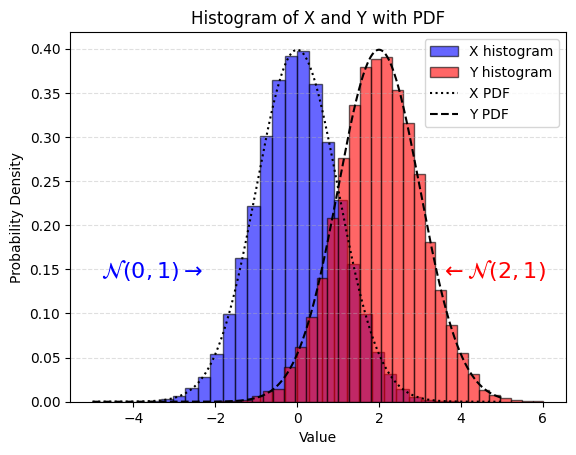

In [154]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

X = np.random.normal(0, 1, 25000)
Y = np.random.normal(2, 1, 25000) #Generation of random numbers


plt.hist(X, bins=30, density=True, color='blue', edgecolor='black', alpha=0.6, label="X histogram")
plt.hist(Y, bins=30, density=True, color='red', edgecolor='black', alpha=0.6, label="Y histogram")

numbers = np.linspace(-5, 5, 1000) #500 numbers from -5 to 5
pdf_X = norm.pdf(numbers, 0, 1)
pdf_Y = norm.pdf(numbers, 2, 1) #Probability density function

plt.plot(numbers, pdf_X, color='black', linestyle=':', label="X PDF")
plt.plot(numbers, pdf_Y, color='black', linestyle='--', label="Y PDF")

plt.title("Histogram of X and Y with PDF")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.text(-4.8, 0.14, r'$\mathcal{N}(0,1) \rightarrow $',
         color='blue', fontsize=16)
plt.text(3.5, 0.14, r'$\leftarrow \mathcal{N}(2,1)$',
         color='red', fontsize=16)
plt.legend()
plt.grid(alpha=0.4, linestyle='--', axis='y')
plt.show()

#1D Histogram

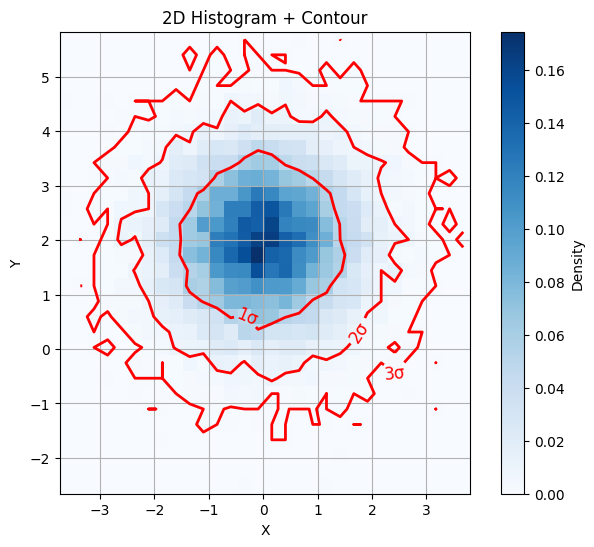

In [160]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data
np.random.seed(0)
X = np.random.normal(0, 1, 17000)
Y = np.random.normal(2, 1, 17000)

# Compute 2D histogram
counts, xedges, yedges = np.histogram2d(X, Y, bins=30, density=True)

# Meshgrid of bin centers
xcenters = (xedges[:-1] + xedges[1:]) / 2
ycenters = (yedges[:-1] + yedges[1:]) / 2
Xg, Yg = np.meshgrid(xcenters, ycenters)

# Compute levels corresponding to 1σ, 2σ, 3σ (68%, 95%, 99.7%)
# 1. Flatten histogram and sort descending
flat_counts = counts.flatten()
sorted_counts = np.sort(flat_counts)[::-1]  # highest density first

# 2. Cumulative sum of probabilities
cumulative = np.cumsum(sorted_counts)
cumulative /= cumulative[-1]  # normalize to 1

# 3. Find density thresholds for sigma levels
sigma_levels = [0.68, 0.95, 0.997]
levels = [sorted_counts[np.searchsorted(cumulative, s)] for s in sigma_levels]
levels = sorted(levels)
# -----------------------
# Plot 2D histogram
# -----------------------
plt.figure(figsize=(8,6))
img = plt.hist2d(X, Y, bins=30, density=True, cmap='Blues')
plt.colorbar(img[3], label='Density')

# Plot contours at sigma levels
contour = plt.contour(Xg, Yg, counts.T, levels=levels, colors='red', linewidths=2)
plt.clabel(contour, inline=True, fmt={l: f'{i}σ' for i, l in enumerate(levels[::-1], 1)}, fontsize=12)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Histogram + Contour')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.show()